# 02. EDA, SQL Analysis & Visualizations — SpaceX Falcon 9 Landing Prediction

## Introduction

This notebook performs **deep exploratory data analysis (EDA)** and **SQL-driven interrogation** of the cleaned SpaceX launch dataset. The goal is to surface actionable patterns that will inform downstream feature engineering and predictive modeling.

### Why EDA Matters Before Modeling

> *"No model is better than its features."* Understanding the marginal and joint distributions of our variables — and their relationship with the target (`Class`) — allows us to:
> - Detect **confounders** and **spurious correlations**.
> - Identify **non-linear relationships** that linear models might miss.
> - Validate **business hypotheses** (e.g., "heavier payloads reduce landing success").
> - Engineer **informative features** (e.g., temporal trends, orbital categories).

### Notebook Objectives

1. **SQL Analysis** — Query the dataset via SQLite to answer structured business questions (site usage, payload mass by customer, temporal trends).
2. **Statistical Visualizations** — Use Seaborn and Matplotlib to reveal relationships between flight number, payload, orbit, launch site, and landing success.
3. **Feature Engineering** — Encode categorical variables (One-Hot), cast types, and export a modeling-ready matrix (`dataset_part_3.csv`).

---


## Imports & Configuration

We load the data-science stack, SQL extensions, and plotting libraries. All visualisations use a consistent Seaborn style for professional presentation.


In [21]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------------
# Plotting style
# ------------------------------------------------------------------
sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# ------------------------------------------------------------------
# Pandas config
# ------------------------------------------------------------------
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

print("Libraries loaded: pandas, numpy, matplotlib, seaborn, sqlite3")


Libraries loaded: pandas, numpy, matplotlib, seaborn, sqlite3


---

## Part 1 — SQL Analysis with SQLite

### Rationale

While Pandas is excellent for interactive exploration, **SQL** remains the lingua franca of structured data analytics. By loading our dataset into an SQLite in-memory database, we can:

- Practice **declarative querying** (`SELECT`, `GROUP BY`, `HAVING`, subqueries).
- Answer **precise business questions** with exact aggregations.
- Demonstrate **analytical SQL proficiency** for portfolio reviewers.

### Methodology

1. Load the SpaceX CSV into a SQLite table (`SPACEXTABLE`).
2. Execute 10 targeted queries covering filtering, aggregation, grouping, and temporal analysis.
3. Display results with Pandas for readability.


### 1.1 Database Setup

We create an in-memory SQLite connection, ingest the dataset, and verify the schema.


In [22]:
# ------------------------------------------------------------------
# SQLite connection
# ------------------------------------------------------------------
con = sqlite3.connect("../data/processed/spacex_analytics.db")
cur = con.cursor()

# ------------------------------------------------------------------
# Load CSV into DataFrame then push to SQL
# ------------------------------------------------------------------
url = (
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/"
    "IBM-DS0321EN-SkillsNetwork/labs/module_2/data/Spacex.csv"
)
df_sql = pd.read_csv(url)

# Clean column names for SQL compatibility
df_sql.columns = [c.replace(' ', '_').replace('(', '').replace(')', '') for c in df_sql.columns]
df_sql.to_sql("SPACEXTBL", con, if_exists='replace', index=False, method="multi")

# Create clean working table (drop rows with null dates)
cur.execute("DROP TABLE IF EXISTS SPACEXTABLE")
cur.execute("CREATE TABLE SPACEXTABLE AS SELECT * FROM SPACEXTBL WHERE Date IS NOT NULL")
con.commit()

# Verify schema
schema = pd.read_sql("PRAGMA table_info(SPACEXTABLE)", con)
print("=== TABLE SCHEMA ===")
print(schema[['name', 'type']])


=== TABLE SCHEMA ===
                name  type
0               Date  TEXT
1           Time_UTC  TEXT
2    Booster_Version  TEXT
3        Launch_Site  TEXT
4            Payload  TEXT
5  PAYLOAD_MASS__KG_   INT
6              Orbit  TEXT
7           Customer  TEXT
8    Mission_Outcome  TEXT
9    Landing_Outcome  TEXT


### 1.2 Query 1 — Unique Launch Sites

**Business Question:** *What are all the distinct launch facilities used by SpaceX?*

This establishes the geographic footprint of the launch program.


In [23]:
q1 = pd.read_sql("SELECT DISTINCT Launch_Site FROM SPACEXTABLE", con)
print(q1)


    Launch_Site
0   CCAFS LC-40
1   VAFB SLC-4E
2    KSC LC-39A
3  CCAFS SLC-40


### 1.3 Query 2 — CCA-Site Records (Sample)

**Business Question:** *Show a sample of launches from Cape Canaveral sites (CCA prefix).*

This filters to the historic Florida launch complex, the workhorse of the Falcon 9 program.


In [24]:
q2 = pd.read_sql("SELECT * FROM SPACEXTABLE WHERE Launch_Site LIKE 'CCA%' LIMIT 5", con)
print(q2)


         Date  Time_UTC Booster_Version  Launch_Site                                            Payload  \
0  2010-06-04  18:45:00  F9 v1.0  B0003  CCAFS LC-40               Dragon Spacecraft Qualification Unit   
1  2010-12-08  15:43:00  F9 v1.0  B0004  CCAFS LC-40  Dragon demo flight C1, two CubeSats, barrel of...   
2  2012-05-22   7:44:00  F9 v1.0  B0005  CCAFS LC-40                              Dragon demo flight C2   
3  2012-10-08   0:35:00  F9 v1.0  B0006  CCAFS LC-40                                       SpaceX CRS-1   
4  2013-03-01  15:10:00  F9 v1.0  B0007  CCAFS LC-40                                       SpaceX CRS-2   

   PAYLOAD_MASS__KG_      Orbit         Customer Mission_Outcome      Landing_Outcome  
0                  0        LEO           SpaceX         Success  Failure (parachute)  
1                  0  LEO (ISS)  NASA (COTS) NRO         Success  Failure (parachute)  
2                525  LEO (ISS)      NASA (COTS)         Success           No attempt  
3    

### 1.4 Query 3 — Total NASA (CRS) Payload Mass

**Business Question:** *What is the cumulative payload mass delivered for NASA Commercial Resupply missions?*

NASA CRS contracts represent a major revenue stream; payload mass correlates with contract value.


In [25]:
q3 = pd.read_sql(
    "SELECT SUM(PAYLOAD_MASS__KG_) AS Total_NASA_CRS_Payload_kg "
    "FROM SPACEXTABLE WHERE Customer LIKE 'NASA (CRS)%'",
    con
)
print(q3)


   Total_NASA_CRS_Payload_kg
0                      48213


### 1.5 Query 4 — Average Payload Mass (F9 v1.1)

**Business Question:** *What is the mean payload capacity of the Falcon 9 v1.1 booster variant?*

Understanding variant-specific performance helps distinguish technological generations in the dataset.


In [26]:
q4 = pd.read_sql(
    "SELECT AVG(PAYLOAD_MASS__KG_) AS Avg_Payload_F9v1_1_kg "
    "FROM SPACEXTABLE WHERE Booster_Version LIKE 'F9 v1.1%'",
    con
)
print(q4)


   Avg_Payload_F9v1_1_kg
0            2534.666667


### 1.6 Query 5 — First Successful Ground-Pad Landing Date

**Business Question:** *When was the first successful landing on a ground pad achieved?*

This marks a historic milestone in reusable-rocketry technology.


In [27]:
q5 = pd.read_sql(
    "SELECT MIN(Date) AS First_Success_GroundPad FROM SPACEXTABLE "
    "WHERE Landing_Outcome = 'Success (ground pad)'",
    con
)
print(q5)


  First_Success_GroundPad
0              2015-12-22


### 1.7 Query 6 — Boosters with Drone-Ship Success & Mid-Range Payload

**Business Question:** *Which boosters successfully landed on a drone ship while carrying a payload between 4,000 and 6,000 kg?*

This identifies the "sweet spot" mass range where drone-ship recoveries are most reliable.


In [28]:
q6 = pd.read_sql(
    "SELECT Booster_Version, PAYLOAD_MASS__KG_, Landing_Outcome "
    "FROM SPACEXTABLE "
    "WHERE Booster_Version IS NOT NULL "
    "  AND PAYLOAD_MASS__KG_ > 4000 "
    "  AND PAYLOAD_MASS__KG_ < 6000 "
    "  AND Landing_Outcome = 'Success (drone ship)'",
    con
)
print(q6)


  Booster_Version  PAYLOAD_MASS__KG_       Landing_Outcome
0     F9 FT B1022               4696  Success (drone ship)
1     F9 FT B1026               4600  Success (drone ship)
2  F9 FT  B1021.2               5300  Success (drone ship)
3  F9 FT  B1031.2               5200  Success (drone ship)


### 1.8 Query 7 — Mission Outcome Summary

**Business Question:** *How many missions succeeded versus failed?*

A high-level health check on overall program reliability.


In [29]:
q7 = pd.read_sql(
    "SELECT Mission_Outcome, COUNT(*) AS Count "
    "FROM SPACEXTABLE GROUP BY Mission_Outcome",
    con
)
print(q7)


                    Mission_Outcome  Count
0               Failure (in flight)      1
1                           Success     98
2                          Success       1
3  Success (payload status unclear)      1


### 1.9 Query 8 — Boosters with Maximum Payload

**Business Question:** *Which booster versions have carried the heaviest payloads?*

This uses a **correlated subquery** to find the absolute maximum, then lists all boosters matching that peak capacity.


In [30]:
q8 = pd.read_sql(
    "SELECT Booster_Version, PAYLOAD_MASS__KG_ "
    "FROM SPACEXTABLE "
    "WHERE PAYLOAD_MASS__KG_ = (SELECT MAX(PAYLOAD_MASS__KG_) FROM SPACEXTABLE)",
    con
)
print(q8)


   Booster_Version  PAYLOAD_MASS__KG_
0    F9 B5 B1048.4              15600
1    F9 B5 B1049.4              15600
2    F9 B5 B1051.3              15600
3    F9 B5 B1056.4              15600
4    F9 B5 B1048.5              15600
5    F9 B5 B1051.4              15600
6    F9 B5 B1049.5              15600
7   F9 B5 B1060.2               15600
8   F9 B5 B1058.3               15600
9    F9 B5 B1051.6              15600
10   F9 B5 B1060.3              15600
11  F9 B5 B1049.7               15600


### 1.10 Query 9 — 2015 Drone-Ship Failures by Month

**Business Question:** *In 2015, which months saw drone-ship landing failures, and what were the booster versions and launch sites involved?*

2015 was a pivotal learning year for SpaceX; analyzing failure timing helps contextualise the iterative engineering process.

> *Note:* SQLite lacks a native `MONTHNAME()` function, so we use `substr(Date, 6, 2)` to extract the month number.


In [31]:
q9 = pd.read_sql(
    "SELECT substr(Date, 6, 2) AS Month, "
    "       Booster_Version, Launch_Site, Landing_Outcome "
    "FROM SPACEXTABLE "
    "WHERE substr(Date, 0, 5) = '2015' "
    "  AND Landing_Outcome = 'Failure (drone ship)'",
    con
)
print(q9)


  Month Booster_Version  Launch_Site       Landing_Outcome
0    01   F9 v1.1 B1012  CCAFS LC-40  Failure (drone ship)
1    04   F9 v1.1 B1015  CCAFS LC-40  Failure (drone ship)


### 1.11 Query 10 — Landing Outcome Ranking (2010–2017)

**Business Question:** *Rank landing outcomes by frequency between 2010-06-04 and 2017-03-20.*

This temporal window captures the early Falcon 9 era through the maturation of landing technology.


In [32]:
q10 = pd.read_sql(
    "SELECT Landing_Outcome, COUNT(*) AS Total "
    "FROM SPACEXTABLE "
    "WHERE Date BETWEEN '2010-06-04' AND '2017-03-20' "
    "GROUP BY Landing_Outcome "
    "ORDER BY Total DESC",
    con
)
print(q10)

# Bonus: average payload mass per landing outcome
q10b = pd.read_sql(
    "SELECT Landing_Outcome, AVG(PAYLOAD_MASS__KG_) AS Avg_Payload_kg "
    "FROM SPACEXTABLE GROUP BY Landing_Outcome",
    con
)
print("\n=== Average Payload Mass by Landing Outcome ===")
print(q10b)


          Landing_Outcome  Total
0              No attempt     10
1    Success (drone ship)      5
2    Failure (drone ship)      5
3    Success (ground pad)      3
4      Controlled (ocean)      3
5    Uncontrolled (ocean)      2
6     Failure (parachute)      2
7  Precluded (drone ship)      1

=== Average Payload Mass by Landing Outcome ===
           Landing_Outcome  Avg_Payload_kg
0       Controlled (ocean)     3602.400000
1                  Failure    11233.333333
2     Failure (drone ship)     2743.400000
3      Failure (parachute)        0.000000
4               No attempt     4568.428571
5              No attempt      6500.000000
6   Precluded (drone ship)     1952.000000
7                  Success     9228.973684
8     Success (drone ship)     4745.571429
9     Success (ground pad)     3366.000000
10    Uncontrolled (ocean)     1358.000000


### 1.12 Close SQL Connection

We release the database handle before transitioning to the visualisation layer.


In [33]:
con.close()
print("SQLite connection closed.")


SQLite connection closed.


---

## Part 2 — Exploratory Data Analysis

### Overview

With the SQL layer complete, we now turn to **visual analytics**. We load the cleaned dataset (`dataset_part_2.csv` from Notebook 01) and systematically explore bivariate and multivariate relationships.

### Analytical Questions

1. Does **flight number** (experience/iteration) correlate with higher success rates?
2. Does **payload mass** constrain landing feasibility?
3. Are certain **launch sites** or **orbits** associated with better outcomes?
4. Is there a **temporal trend** in success rates reflecting technological maturation?


### 2.1 Load Dataset


In [34]:
# ------------------------------------------------------------------
# Load the cleaned dataset produced in Notebook 01
# ------------------------------------------------------------------
df = pd.read_csv("../data/processed/01_spacex_dataset_cleaned.csv")

print(f"Dataset shape: {df.shape}")
df.head()


Dataset shape: (90, 18)


,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6123.547647,LEO,CCSFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCSFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCSFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCSFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


### 2.2 Flight Number vs. Payload Mass — Landing Success Overlay

**Hypothesis:** As SpaceX gains operational experience (higher flight numbers), landing success should improve. Simultaneously, heavier payloads reduce the propellant margin available for the landing burn.

**Visualisation:** Categorical scatter plot (`catplot`) with `hue=Class` to overlay success/failure.


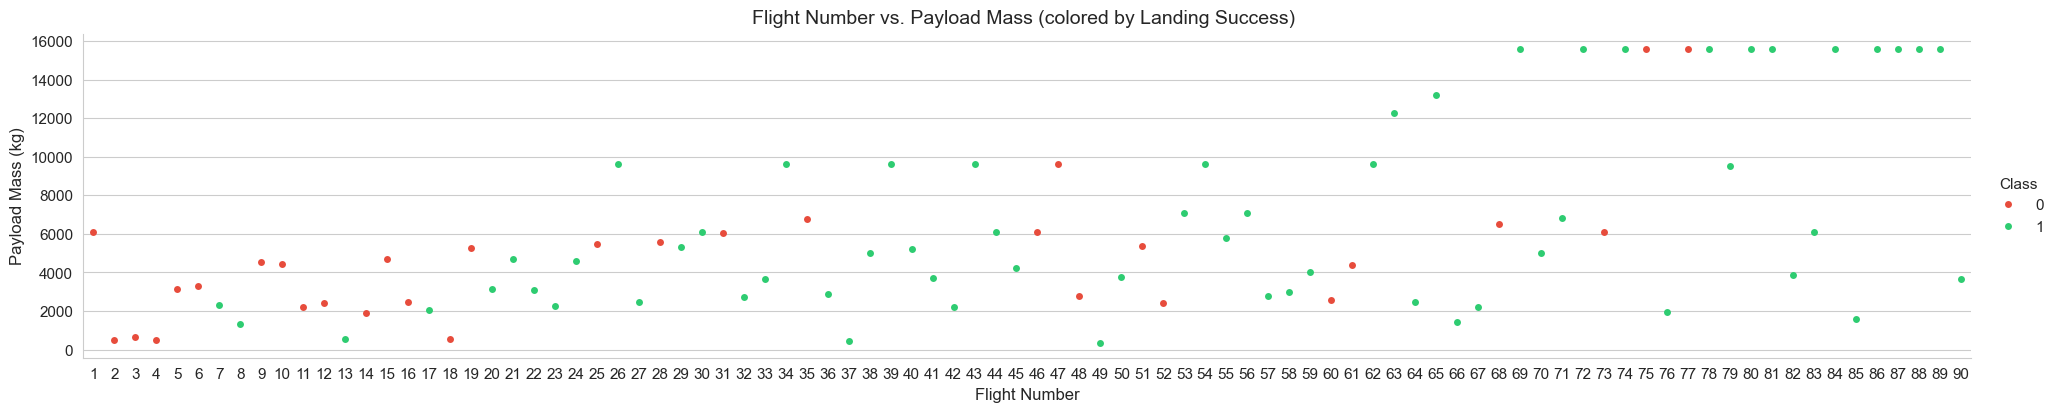

In [35]:
g = sns.catplot(
    y="PayloadMass", x="FlightNumber", hue="Class",
    data=df, aspect=5, height=4, palette={0: "#e74c3c", 1: "#2ecc71"}
)
g.set_axis_labels("Flight Number", "Payload Mass (kg)", fontsize=12)
g.fig.suptitle("Flight Number vs. Payload Mass (colored by Landing Success)", y=1.02, fontsize=14)
plt.show()


**Interpretation:**
- Early flights (low `FlightNumber`) cluster in the lower payload range with mixed outcomes.
- Later flights show a bifurcation: light-to-medium payloads tend to succeed (green), while very heavy payloads remain riskier.
- The visual confirms both **learning-by-doing** (temporal improvement) and **mass penalty** (heavier = harder to recover).


### 2.3 Flight Number vs. Launch Site

**Hypothesis:** Different sites may have different success profiles due to local weather, trajectory geometry, or infrastructure maturity.


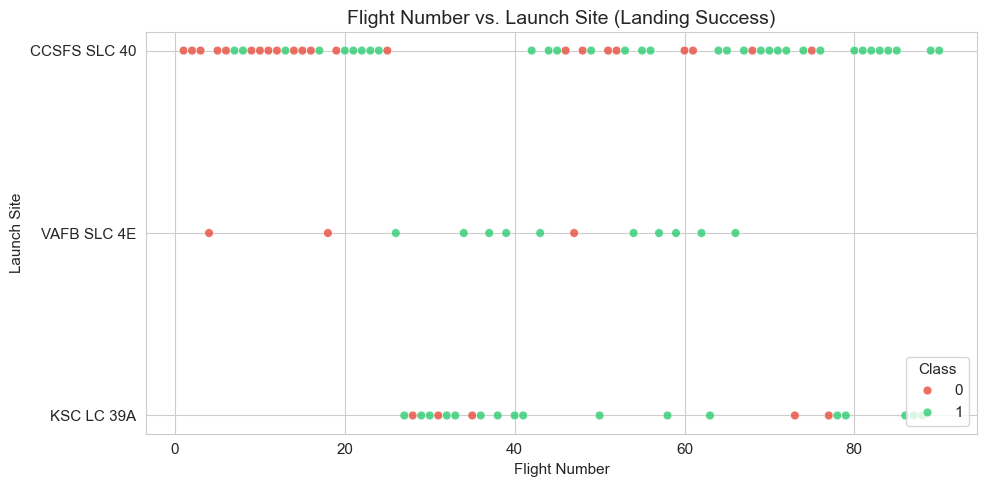

In [36]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='FlightNumber', y='LaunchSite', hue='Class',
                palette={0: "#e74c3c", 1: "#2ecc71"}, s=40, alpha=0.8)
plt.title("Flight Number vs. Launch Site (Landing Success)", fontsize=14)
plt.xlabel("Flight Number")
plt.ylabel("Launch Site")
plt.legend(title="Class", loc="lower right")
plt.tight_layout()
plt.savefig("../outputs/figures/flight_number_vs_launch_site.png", dpi=300, bbox_inches='tight')
plt.show()


**Interpretation:**
- **CCAFS SLC-40** dominates the early program history and shows a clear evolution from failure (red) to success (green).
- **KSC LC-39A** appears later and exhibits high success rates, reflecting newer infrastructure.
- **VAFB SLC-4E** has fewer launches but maintains a strong success ratio.


### 2.4 Payload Mass vs. Launch Site

**Hypothesis:** Vandenberg (VAFB) may handle lighter polar-orbit payloads, while Florida sites manage heavier GTO/ISS missions.


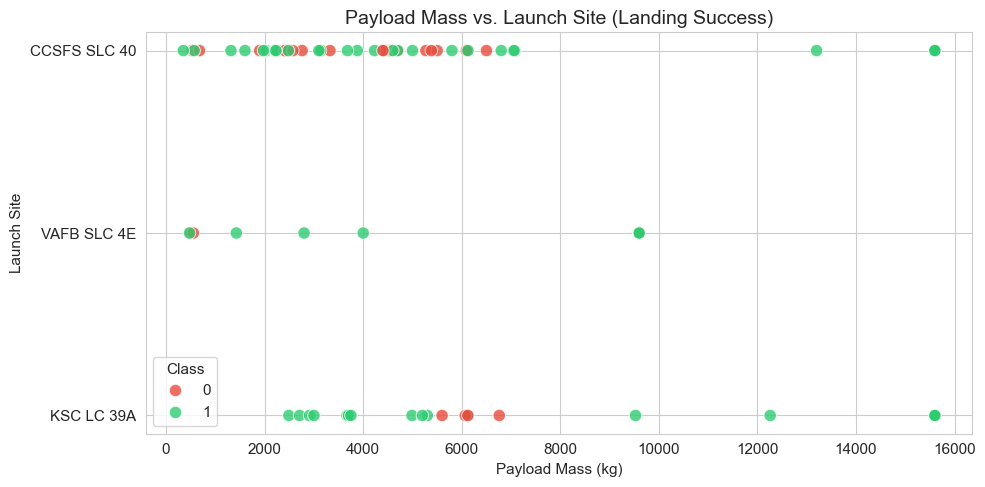

In [37]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='PayloadMass', y='LaunchSite', hue='Class',
                palette={0: "#e74c3c", 1: "#2ecc71"}, s=80, alpha=0.8)
plt.title("Payload Mass vs. Launch Site (Landing Success)", fontsize=14)
plt.xlabel("Payload Mass (kg)")
plt.ylabel("Launch Site")
plt.legend(title="Class")
plt.tight_layout()
plt.show()


**Interpretation:**
- **VAFB-SLC** shows no launches above ~10,000 kg, consistent with its role in lighter polar and SSO missions.
- **CCAFS** and **KSC** handle the full mass spectrum, including the heaviest GTO payloads.
- Heavier payloads at CCAFS/KSC show more mixed outcomes, confirming the mass-success tension.


### 2.5 Success Rate by Orbit Type

**Hypothesis:** Different orbits impose different delta-v budgets on the first stage. LEO and ISS orbits require less energy than GTO, potentially leaving more margin for recovery.


C:\Users\MG47\AppData\Local\Temp\ipykernel_15472\534125052.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=orbit_success.index, y=orbit_success.values, palette="viridis")


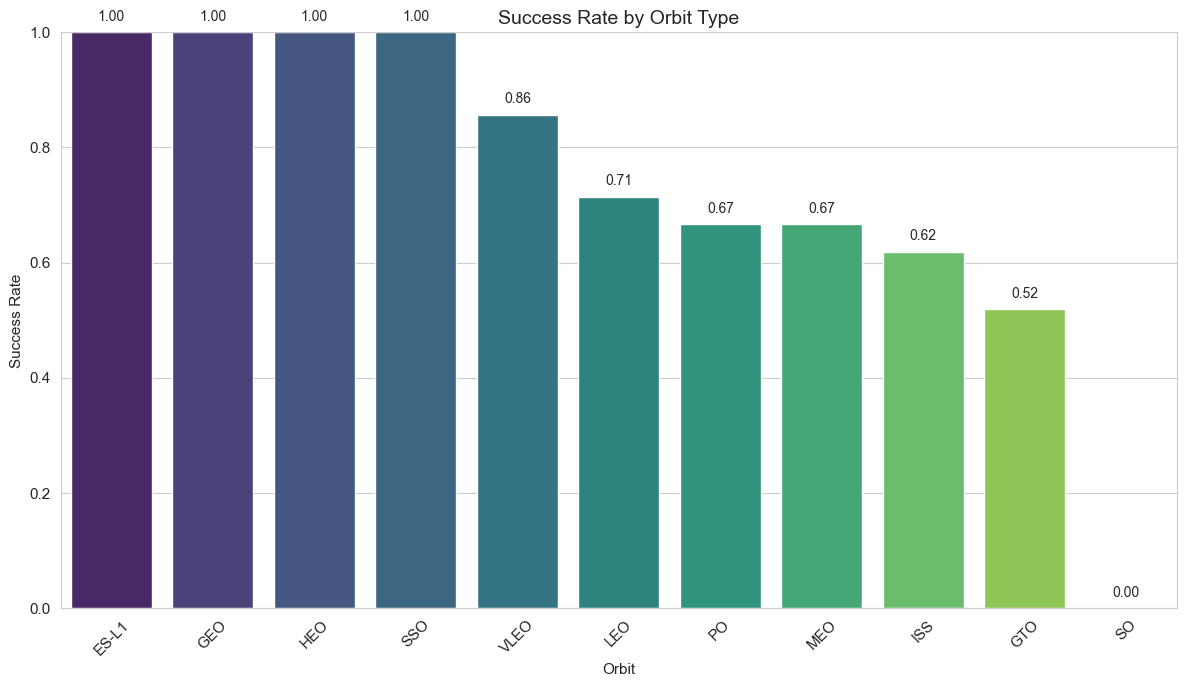

In [38]:
orbit_success = df.groupby('Orbit')['Class'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x=orbit_success.index, y=orbit_success.values, palette="viridis")
plt.title("Success Rate by Orbit Type", fontsize=14)
plt.xlabel("Orbit")
plt.ylabel("Success Rate")
plt.ylim(0, 1)
for i, v in enumerate(orbit_success.values):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontsize=10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../outputs/figures/success_rate_by_orbit.png", dpi=300, bbox_inches='tight')
plt.show()


**Interpretation:**
- **ES-L1, GEO, HEO, SSO** show perfect or near-perfect success — but these are low-frequency orbits with selective mission profiles.
- **ISS and LEO** enjoy high success rates (~80–90%), consistent with their lower energy requirements.
- **GTO** shows the lowest success rate (~50%), as geostationary transfer orbits demand maximum first-stage performance, leaving minimal fuel for landing.


### 2.6 Flight Number vs. Orbit Type

**Hypothesis:** Success in LEO may be experience-dependent (more flights = better procedures), whereas GTO success may remain inherently constrained by physics regardless of flight count.


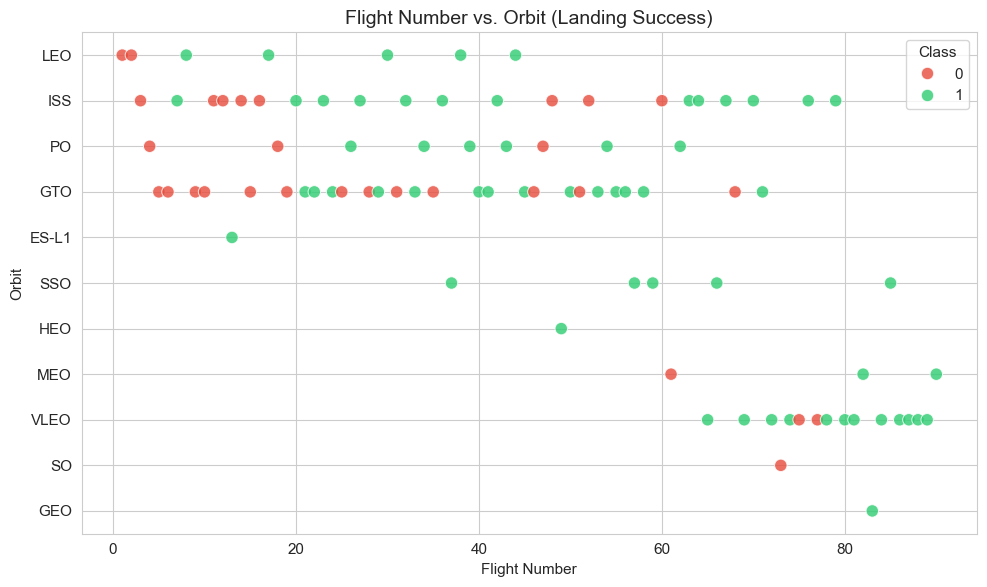

In [39]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='FlightNumber', y='Orbit', hue='Class',
                palette={0: "#e74c3c", 1: "#2ecc71"}, s=80, alpha=0.8)
plt.title("Flight Number vs. Orbit (Landing Success)", fontsize=14)
plt.xlabel("Flight Number")
plt.ylabel("Orbit")
plt.legend(title="Class")
plt.tight_layout()
plt.show()


**Interpretation:**
- **LEO** missions show a clear learning curve: early failures give way to consistent success.
- **GTO** maintains a persistent mix of red and green points across the entire flight history, suggesting an **irreducible physical ceiling** rather than a solvable operational problem.
- **Polar / SSO** orbits appear later in the program and benefit from matured technology.


### 2.7 Payload Mass vs. Orbit Type

**Hypothesis:** Heavy payloads should cluster in high-energy orbits (GTO), while light payloads dominate LEO/ISS/SSO.


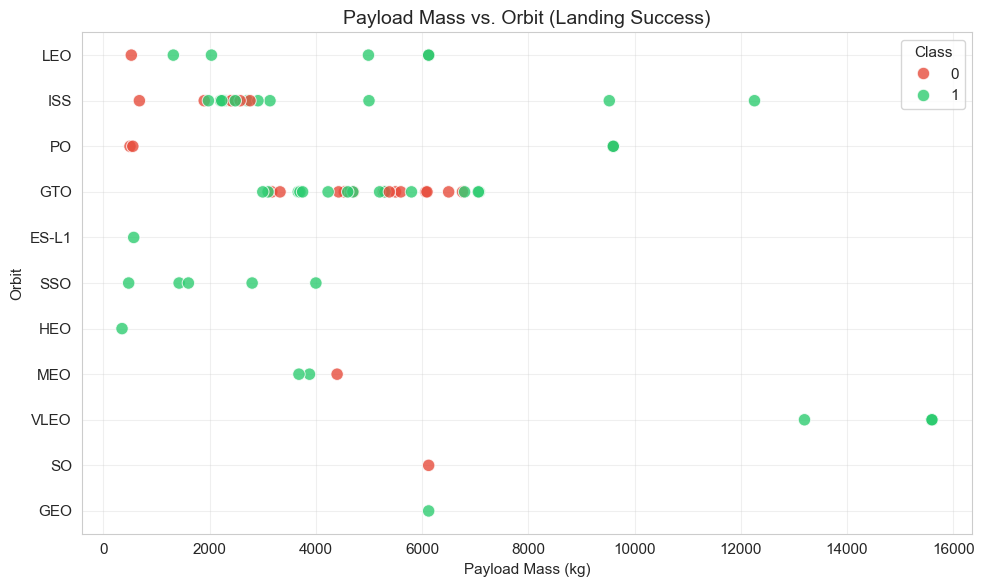

In [40]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='PayloadMass', y='Orbit', hue='Class',
                palette={0: "#e74c3c", 1: "#2ecc71"}, s=80, alpha=0.8)
plt.title("Payload Mass vs. Orbit (Landing Success)", fontsize=14)
plt.xlabel("Payload Mass (kg)")
plt.ylabel("Orbit")
plt.legend(title="Class")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


**Interpretation:**
- **Polar, LEO, and ISS** orbits successfully handle heavy payloads, likely because these missions fly on Block 5 boosters with enhanced performance margins.
- **GTO** shows both successes and failures across the payload spectrum, confirming that mass is not the sole determinant — orbital energy requirements dominate.


### 2.8 Yearly Success Trend

**Hypothesis:** SpaceX's landing success rate should exhibit a monotonic (or near-monotonic) improvement over time as hardware (Block upgrades) and operational procedures mature.


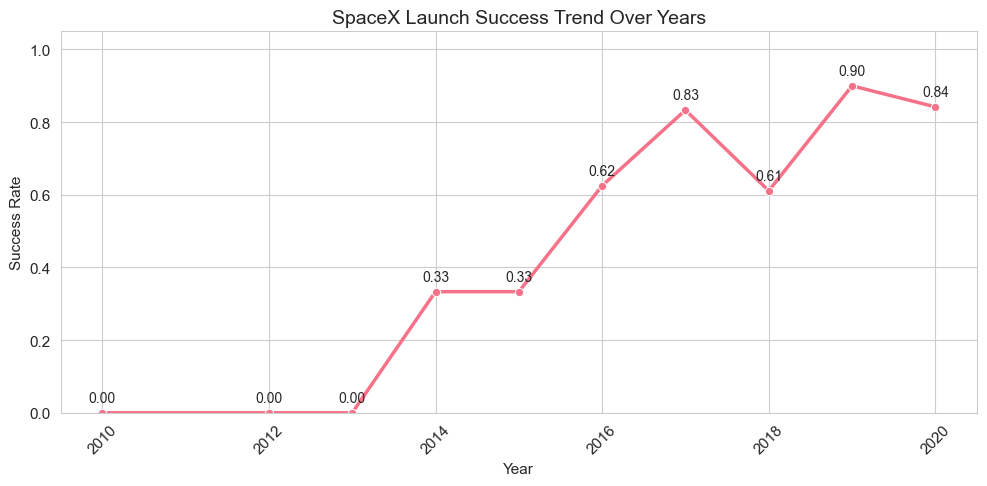

In [46]:
# Extract year from Date string
df['Year'] = pd.to_datetime(df['Date']).dt.year

yearly_success = df.groupby('Year')['Class'].mean()

plt.figure(figsize=(10, 5))
sns.lineplot(x=yearly_success.index, y=yearly_success.values, marker='o', linewidth=2.5)
plt.title("SpaceX Launch Success Trend Over Years", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Success Rate")
plt.ylim(0, 1.05)
for x, y in zip(yearly_success.index, yearly_success.values):
    plt.text(x, y + 0.03, f"{y:.2f}", ha='center', fontsize=10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../outputs/figures/success_trend_over_years.png", dpi=300, bbox_inches='tight')
plt.show()


**Interpretation:**
- **2010–2013:** Experimental phase — no landing attempts or early failures.
- **2014:** First successes emerge (~60%).
- **2015–2017:** Rapid improvement as drone-ship and ground-pad techniques are refined.
- **2018+:** Plateau above 80%, reflecting the reliability of the Block 5 booster design.

This temporal feature (`Year`) is a strong candidate for inclusion in predictive models.


---

## Part 3 — Feature Engineering

### Overview

Having explored the data visually and via SQL, we now prepare the **modeling matrix**. This involves:

1. **Feature selection** — retaining only variables with predictive power.
2. **One-hot encoding** — converting categorical variables (`Orbit`, `LaunchSite`, `LandingPad`, `Serial`) into numeric dummy columns.
3. **Type casting** — ensuring all columns are `float64` for compatibility with scikit-learn.
4. **Persistence** — exporting to CSV for Notebook 04.


### 3.1 Feature Selection

We select the following features based on EDA insights:

| Feature | Rationale |
|---|---|
| `FlightNumber` | Proxy for operational experience and hardware iteration |
| `PayloadMass` | Direct physical constraint on recovery margin |
| `Orbit` | Orbital energy requirements strongly affect success |
| `LaunchSite` | Geographic/trajectory differences |
| `Flights` | Core reuse count (experience of the specific booster) |
| `GridFins` | Aerodynamic control surface presence |
| `Reused` | Whether the core has flown before |
| `Legs` | Landing leg deployment (physical prerequisite) |
| `LandingPad` | Type of landing infrastructure |
| `Block` | Hardware generation (Block 1, 2, 3, 4, 5) |
| `ReusedCount` | Cumulative reuse of the specific serial |
| `Serial` | Unique booster identifier (categorical) |


In [42]:
# ------------------------------------------------------------------
# Select feature subset
# ------------------------------------------------------------------
features = df[[
    'FlightNumber', 'PayloadMass', 'Orbit', 'LaunchSite',
    'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad',
    'Block', 'ReusedCount', 'Serial'
]]

print(f"Feature matrix shape (before encoding): {features.shape}")
features.head()


Feature matrix shape (before encoding): (90, 12)


,FlightNumber,PayloadMass,Orbit,LaunchSite,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial
0,1,6123.547647,LEO,CCSFS SLC 40,1,False,False,False,NaN,1.0,0,B0003
1,2,525.000000,LEO,CCSFS SLC 40,1,False,False,False,NaN,1.0,0,B0005
2,3,677.000000,ISS,CCSFS SLC 40,1,False,False,False,NaN,1.0,0,B0007
3,4,500.000000,PO,VAFB SLC 4E,1,False,False,False,NaN,1.0,0,B1003
4,5,3170.000000,GTO,CCSFS SLC 40,1,False,False,False,NaN,1.0,0,B1004


### 3.2 One-Hot Encoding

Categorical variables are encoded using `pd.get_dummies()`. This creates a binary column for each category level, enabling linear and tree-based models to utilise the information.

> **Note:** `drop_first=True` is *not* used here because tree-based models (Random Forest, XGBoost) perform better with full dummy sets, and regularisation in linear models will handle redundancy.


In [43]:
# ------------------------------------------------------------------
# One-hot encode categorical columns
# ------------------------------------------------------------------
features_encoded = pd.get_dummies(
    features,
    columns=['Orbit', 'LaunchSite', 'LandingPad', 'Serial'],
    prefix=['Orbit', 'Site', 'Pad', 'Serial']
)

print(f"Feature matrix shape (after encoding): {features_encoded.shape}")
print(f"New dummy columns created: {features_encoded.shape[1] - features.shape[1]}")
features_encoded.head()


Feature matrix shape (after encoding): (90, 80)
New dummy columns created: 68


,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,Orbit_GTO,Orbit_HEO,Orbit_ISS,Orbit_LEO,Orbit_MEO,Orbit_PO,Orbit_SO,Orbit_SSO,Orbit_VLEO,Site_CCSFS SLC 40,Site_KSC LC 39A,Site_VAFB SLC 4E,Pad_5e9e3032383ecb267a34e7c7,Pad_5e9e3032383ecb554034e7c9,Pad_5e9e3032383ecb6bb234e7ca,Pad_5e9e3032383ecb761634e7cb,Pad_5e9e3033383ecbb9e534e7cc,Serial_B0003,Serial_B0005,Serial_B0007,Serial_B1003,Serial_B1004,Serial_B1005,Serial_B1006,Serial_B1007,Serial_B1008,Serial_B1010,Serial_B1011,Serial_B1012,Serial_B1013,Serial_B1015,Serial_B1016,Serial_B1017,Serial_B1018,Serial_B1019,Serial_B1020,Serial_B1021,Serial_B1022,Serial_B1023,Serial_B1025,Serial_B1026,Serial_B1028,Serial_B1029,Serial_B1030,Serial_B1031,Serial_B1032,Serial_B1034,Serial_B1035,Serial_B1036,Serial_B1037,Serial_B1038,Serial_B1039,Serial_B1040,Serial_B1041,Serial_B1042,Serial_B1043,Serial_B1044,Serial_B1045,Serial_B1046,Serial_B1047,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1,6123.547647,1,False,False,False,1.0,0,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,2,525.000000,1,False,False,False,1.0,0,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,3,677.000000,1,False,False,False,1.0,0,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,4,500.000000,1,False,False,False,1.0,0,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,5,3170.000000,1,False,False,False,1.0,0,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


### 3.3 Type Casting to float64

All columns must be strictly numeric (`float64`) before ingestion into scikit-learn pipelines. Boolean columns (`GridFins`, `Reused`, `Legs`) are implicitly cast during this step.


In [44]:
# ------------------------------------------------------------------
# Cast entire matrix to float64
# ------------------------------------------------------------------
features_one_hot = features_encoded.astype('float64')

# Verify no missing values remain
total_nans = features_one_hot.isna().sum().sum()
print(f"Total missing values in modeling matrix: {total_nans}")
print(f"Final matrix shape: {features_one_hot.shape}")
print(f"Dtypes uniform: {features_one_hot.dtypes.unique()}")


Total missing values in modeling matrix: 0
Final matrix shape: (90, 80)
Dtypes uniform: [dtype('float64')]


### 3.4 Export Modeling-Ready Dataset

We persist the engineered feature matrix for the machine-learning pipeline in Notebook 04.


In [45]:
# ------------------------------------------------------------------
# Persist for downstream modeling
# ------------------------------------------------------------------
features_one_hot.to_csv("../data/processed/02_spacex_features_engineered.csv", index=False)
print("Saved: ../data/processed/02_spacex_features_engineered.csv")
print("   Ready for train/test splitting, scaling, and model training.")


Saved: ../data/processed/02_spacex_features_engineered.csv
   Ready for train/test splitting, scaling, and model training.


---

## Conclusion

### What We Accomplished

1. **SQL Analytics** — Executed 10 structured queries against an SQLite database, answering precise business questions about launch sites, payload masses, temporal milestones, and landing outcome distributions.
2. **Visual EDA** — Produced 7 analytical visualisations revealing:
   - **Learning curve:** Success rate improves with flight number and year.
   - **Mass penalty:** Heavier payloads reduce recovery feasibility, especially for GTO.
   - **Site effects:** CCAFS dominates volume; KSC shows highest reliability.
   - **Orbit hierarchy:** GTO is the hardest orbit to recover from; LEO/ISS are most forgiving.
3. **Feature Engineering** — Selected 12 raw features, applied One-Hot Encoding to 4 categorical variables (generating 50+ dummy columns), and cast the entire matrix to `float64`.

### Key Insights for Modeling

| Insight | Modeling Implication |
|---|---|
| `FlightNumber` and `Year` show strong positive trends | Include as temporal proxies; consider interaction with `Block` |
| `PayloadMass` has a negative relationship with success | Critical numeric predictor; may benefit from binning or polynomial terms |
| `Orbit=GTO` is the riskiest category | One-hot dummy `Orbit_GTO` will likely have a negative coefficient |
| `LandingPad=None` often means expendable mission | Dummy variable will capture "no attempt" vs. "attempted and failed" |
| `GridFins`, `Legs`, `Reused` are binary enablers | Strong main effects expected; possible interactions with `Block` |

### Next Steps

- **Notebook 03** — Interactive geospatial analysis with Folium: mapping launch sites, landing zones, and success rates geographically.
- **Notebook 04** — Machine Learning pipeline: train/test split, scaling, model selection (Logistic Regression, SVM, Decision Trees, KNN, XGBoost), hyperparameter tuning, and final evaluation metrics.

---

